# Logic operations classifier

This notebook trains a neural network to simultaneously predict the results of AND, OR and XOR logic operations for 2-bit binary inputs.

# 1. Setup and Imports

In [31]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from IPython.display import display

# Configure GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 2. Dataset: generation

In [32]:
# Inputs (X) and Targets (y)
X_np = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_np = np.array([[0, 0, 0], [0, 1, 1], [0, 1, 1], [1, 1, 0]], dtype=np.float32) # [AND, OR, XOR]

# Move to GPU
X = torch.from_numpy(X_np).to(device)
y = torch.from_numpy(y_np).to(device)

print("Inputs (X):\n", X_np)
print("\nTargets (y) [AND, OR, XOR]:\n", y_np)

Inputs (X):
 [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]

Targets (y) [AND, OR, XOR]:
 [[0. 0. 0.]
 [0. 1. 1.]
 [0. 1. 1.]
 [1. 1. 0.]]


# 3. Model definition

In [33]:
class LogicNet(nn.Module):
    def __init__(self):
        super(LogicNet, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 3),
            nn.Sigmoid() # Squashes output between 0 and 1
        )

    def forward(self, x):
        return self.net(x)

model = LogicNet().to(device)

# 4. Training

Training complete.
Last loss: 1.741354651585425e-07


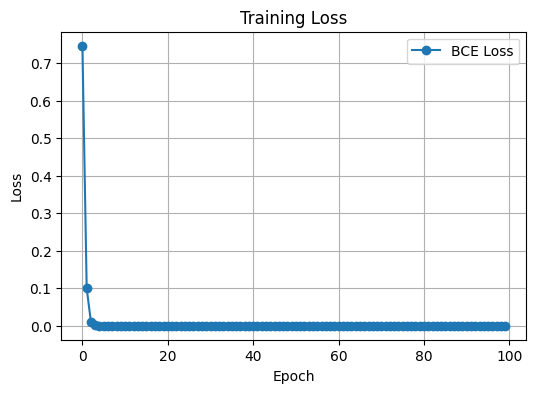

In [34]:
# Loss function: Binary Cross Entropy (BCE)
criterion = nn.BCELoss()

# LBFGS usually converges for logic gates in 1-2 steps
optimizer = optim.LBFGS(model.parameters(), lr=0.1)

# Train
epochs = 100
loss_history = []
for epoch in range(epochs):
    def closure():
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        return loss
    loss = optimizer.step(closure)
    loss_history.append(loss.item())

print("Training complete.")
print("Last loss: " + str(loss.item()))

# Plot loss
plt.figure(figsize=(6, 4))
plt.plot(loss_history, marker='o', label='BCE Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

# 5. Evaluation and Visualization

Input		Pred AND	Pred OR		Pred XOR
[0. 0.]		0		0		0
[0. 1.]		0		1		1
[1. 0.]		0		1		1
[1. 1.]		1		1		0


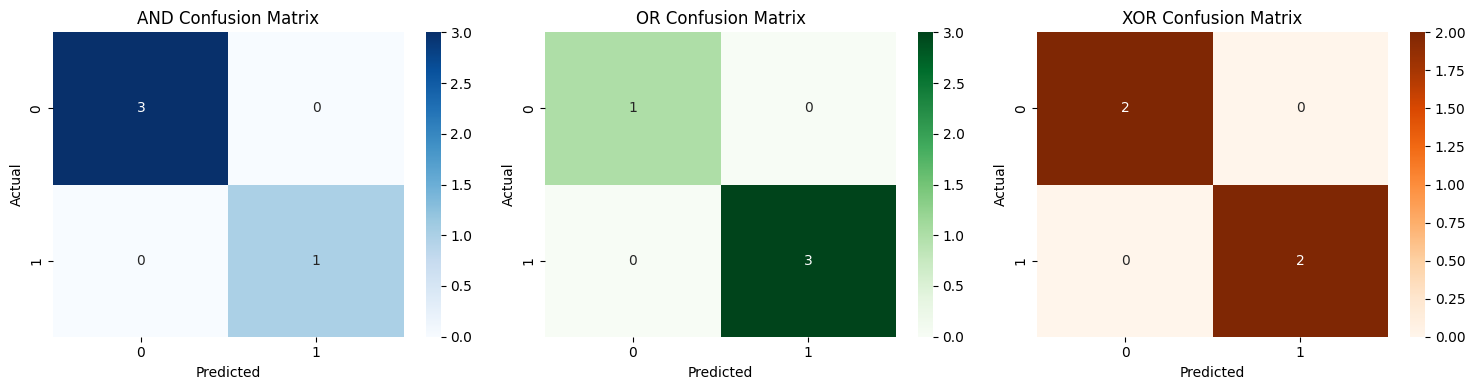

In [35]:
model.eval()
with torch.no_grad():
    predictions = model(X).cpu().numpy()
    binary_preds = (predictions > 0.5).astype(int)

# Print results
print("Input\t\tPred AND\tPred OR\t\tPred XOR")
for i in range(4):
    print(f"{X_np[i]}\t\t{binary_preds[i][0]}\t\t{binary_preds[i][1]}\t\t{binary_preds[i][2]}")

# Plot Confusion Matrices
from sklearn.metrics import confusion_matrix
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
cmaps = ['Blues', 'Greens', 'Oranges']

for i, name in enumerate(['AND', 'OR', 'XOR']):
    cm = confusion_matrix(y_np[:, i], binary_preds[:, i])
    sns.heatmap(cm, annot=True, fmt='g', ax=ax[i], cmap=cmaps[i])
    ax[i].set_title(f'{name} Confusion Matrix')
    ax[i].set_xlabel('Predicted')
    ax[i].set_ylabel('Actual')
plt.tight_layout()
plt.show()

# 6. Export Model

Export the trained model and scaler to JSON (for manual inspection) and ONNX (standard format for cross-platform inference).

In [36]:
# 1. Export to JSON (Parameters)
model_data = {
    "weights": [p.detach().cpu().numpy().T.tolist() for p in model.parameters() if p.dim() > 1],
    "biases": [p.detach().cpu().numpy().tolist() for p in model.parameters() if p.dim() == 1],
    # Since we skipped the scaler in PyTorch, we can set these to defaults
    "scaler_mean": [0.0, 0.0],
    "scaler_scale": [1.0, 1.0]
}

with open("logic_ops_params.json", "w") as f:
    json.dump(model_data, f, indent=4)

# 2. Export to ONNX
dummy_input = torch.randn(1, 2).to(device) # Create a sample input of the correct shape

torch.onnx.export(
    model, 
    dummy_input, 
    "logic_ops_params.onnx",
    input_names=['float_input'],
    output_names=['output'],
    dynamic_axes={'float_input': {0: 'batch_size'}, 'output': {0: 'batch_size'}}
)

print("Model exported to JSON and ONNX successfully.")

C:\Users\juanma\AppData\Local\Temp\ipykernel_4028\1061546054.py:16: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `LogicNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `LogicNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Model exported to JSON and ONNX successfully.


C:\Users\juanma\AppData\Local\Programs\Python\Python313\Lib\copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
